In [4]:
from dotenv import load_dotenv
load_dotenv()

import os

In [5]:
hf_token=os.getenv("HF_TOKEN")

In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image, display


In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

# Functional API

```mermaid
flowchart TD
    A[User Input: 'Write me a joke about cats']
    --> B[Router LLM]

    B --> C[Structured Output Schema: Route]

    C --> D[LLM decides: step='joke']

    D --> E{router_workflow}

    E -->|story| F[llm_call_1]
    E -->|joke| G[llm_call_2]
    E -->|poem| H[llm_call_3]

    F --> I[Return Output]
    G --> I
    H --> I
```

```mermaid
sequenceDiagram

    participant U as User
    participant W as Workflow
    participant R as Router LLM
    participant T as Route Schema
    participant J as Joke Task

    U->>W: "Write me a joke about cats"

    W->>R: Determine which task to run

    R->>T: What outputs are allowed?
    T-->>R: story, joke, poem

    R-->>W: Route(step="joke")

    W->>J: Run joke task

    J-->>W: Generated joke

    W-->>U: Final response
```

In [8]:
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain.messages import HumanMessage, SystemMessage
from langgraph.func import task,entrypoint

In [37]:
# schema for structured o/p to use as a routing logic

class Route(BaseModel):
    step:Literal["poem","story","joke"]=Field(None,description="the next step is the routing process")

In [43]:
#augment the LLM with the schema for structured output

router=llm.with_structured_output(Route,method="json_schema")

@task
def llm_call1(input_:str):
    """Write a story"""
    result=llm.invoke(input_)
    return result.content

@task
def llm_call2(input_:str):
    """Write a joke"""
    result=llm.invoke(input_)
    return result.content

@task
def llm_call3(input_:str):
    """Write a poem"""
    result=llm.invoke(input_)
    return result.content

In [44]:
def llm_call_router(input_:str):
    """ROute thr input to appropriate node"""
    #run the augmented LLM with the structured output to serve as routing logic
    decision=router.invoke(
        [
            SystemMessage(
                content="Route the input to story,joke or poem based on user input"
            ),
            HumanMessage(content=input_)
        ]
    )

    return decision.step

In [45]:
# cretae workflow

@entrypoint()
def router_workflow(input_:str):
    next_step=llm_call_router(input_)
    if next_step=="story":
        llm_call=llm_call1
    elif next_step=="joke":
        llm_call=llm_call2
    elif next_step=="poem":
        llm_call=llm_call3

    return llm_call(input_).result()

In [46]:
#invoke

stream=router_workflow.stream_events("Write me a joke about cats",version='v3')
for snapshot in stream.values:
    print(snapshot)
    print('\m')

[{'type': 'text', 'text': 'Why did the cat sit on the computer keyboard?\n\nBecause it wanted to keep an eye on the mouse!', 'index': 0}]
\m


# graph API

In [9]:

from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


In [10]:
#state

class State(TypedDict):
    input:str
    decision:str
    output:str
    

In [14]:
#nodes

def llm_call1(state:State):
    """Write a story"""
    result=llm.invoke(state['input'])
    return {"output":result.content}

def llm_call2(state:State):
    """Write a joke"""
    result=llm.invoke(state['input'])
    return {"output":result.content}

def llm_call3(state:State):
    """Write a poem"""
    result=llm.invoke(state['input'])
    return {"output":result.content}

def llm_call_router(state:State):
    """Route the input to the appropriate nodes"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}

In [15]:
#conditional edge function to route to the appropriate node

def route_decision(state:State):
    #return the node name you want to visit
    if state['decision']=='story':
        return "llm_call1"
    elif state['decision']=='joke':
        return "llm_call2"
    elif state['decision']=="poem":
        return "llm_call3"

In [16]:
#build workflow

router_builder=StateGraph(State)

# add nodes
router_builder.add_node("llm_call1",llm_call1)
router_builder.add_node("llm_call2",llm_call2)
router_builder.add_node("llm_call3",llm_call3)
router_builder.add_node("llm_call_router",llm_call_router)

In [18]:
#add edges to node

router_builder.add_edge(START,"llm_call_router")

router_builder.add_conditional_edges("llm_call_router",
                                    route_decision,
                                    {#name returned by route_decson: name of node to visit
                                        "llm_call1":"llm_call1",
                                        "llm_call2":"llm_call2",
                                        "llm_call3":"llm_call3"
                                        
                                    }
                                   )

In [19]:
router_builder.add_edge("llm_call1",END)
router_builder.add_edge("llm_call2",END)
router_builder.add_edge("llm_call3",END)



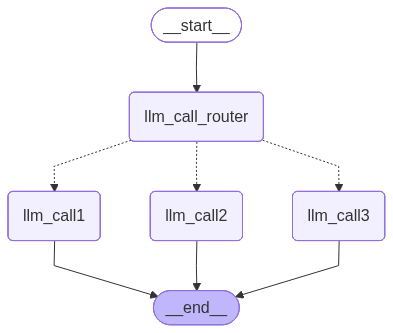

In [21]:
#COMPILE WORKFLOW

router_workflow=router_builder.compile()

#show the workflow

display(Image(router_workflow.get_graph().draw_mermaid_png()))

In [22]:
#invoke

state=router_workflow.invoke({"input":"Write a joke about cats"})

print(state["output"])

Why did the cat sit on the computer?

To keep an eye on the mouse!
